In [ ]:
# This connects Colab to your Google account so it can access your BigQuery project
from google.colab import auth
auth.authenticate_user()

print("Authentication successful")

Authentication successful


In [ ]:
# pandas-gbq lets us run BigQuery queries and get results as a pandas DataFrame
!pip install pandas-gbq -q

import pandas as pd
import pandas_gbq

print("Libraries ready")

Libraries ready


In [ ]:
# Replace with your actual GCP project ID (check it in BigQuery console top-left)
PROJECT_ID = "kimia-harma-analytics-1"

In [ ]:
# This SQL query pulls all rows from tabel_analisa in BigQuery
query = """
SELECT *
FROM `kimia_farma.tabel_analisa`
"""

# Run the query and load results into a pandas DataFrame
df = pandas_gbq.read_gbq(query, project_id=PROJECT_ID)

print("Rows loaded:", df.shape[0])
print("Columns:", df.columns.tolist())

Downloading: 100%|██████████|
Rows loaded: 672458
Columns: ['transaction_id', 'date', 'branch_id', 'branch_name', 'kota', 'provinsi', 'rating_cabang', 'customer_name', 'product_id', 'product_name', 'actual_price', 'discount_percentage', 'persentase_gross_laba', 'nett_sales', 'nett_profit', 'rating_transaksi']


In [ ]:
# Convert date column to datetime and extract year
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# Aggregate total nett sales, nett profit, and transaction count per year
yearly = df.groupby('year').agg(
    total_nett_sales=('nett_sales', 'sum'),
    total_nett_profit=('nett_profit', 'sum'),
    total_transaksi=('transaction_id', 'count')
).reset_index()

# Calculate year-over-year growth percentage
yearly['growth_percent'] = yearly['total_nett_sales'].pct_change() * 100

print(yearly)

   year  total_nett_sales  total_nett_profit  total_transaksi  growth_percent
0  2020      8.043761e+10       2.284236e+10           168651             NaN
1  2021      8.003785e+10       2.273117e+10           167697       -0.496979
2  2022      8.057845e+10       2.288360e+10           168642        0.675429
3  2023      8.011729e+10       2.275786e+10           167468       -0.572303


In [ ]:
# Top 10 provinces by total number of transactions
top_trx_provinsi = df.groupby('provinsi')['transaction_id'].count().sort_values(ascending=False).head(10)
print("=== Top 10 Province - Number of Transactions ===")
print(top_trx_provinsi)

print()

# Top 10 provinces by total nett sales
top_sales_provinsi = df.groupby('provinsi')['nett_sales'].sum().sort_values(ascending=False).head(10)
print("=== Top 10 Province - Total Nett Sales ===")
print(top_sales_provinsi)

=== Top 10 Province - Number of Transactions ===
provinsi
Jawa Barat             198723
Sumatera Utara          48178
Jawa Tengah             46494
Jawa Timur              34766
Sulawesi Utara          33339
Sumatera Barat          32014
Aceh                    21825
Nusa Tenggara Barat     21069
Kalimantan Timur        20243
Riau                    19607
Name: transaction_id, dtype: int64

=== Top 10 Province - Total Nett Sales ===
provinsi
Jawa Barat             9.486959e+10
Sumatera Utara         2.295216e+10
Jawa Tengah            2.224810e+10
Jawa Timur             1.662708e+10
Sulawesi Utara         1.590276e+10
Sumatera Barat         1.531441e+10
Aceh                   1.046797e+10
Nusa Tenggara Barat    1.003674e+10
Kalimantan Timur       9.714537e+09
Riau                   9.354616e+09
Name: nett_sales, dtype: float64


In [ ]:
# Aggregate branch-level stats: overall branch rating, average transaction rating, and transaction count
branch_summary = df.groupby(['branch_id', 'branch_name', 'kota']).agg(
    rating_cabang=('rating_cabang', 'first'),
    avg_rating_transaksi=('rating_transaksi', 'mean'),
    jumlah_transaksi=('transaction_id', 'count')
).reset_index()

# Filter branches with at least 30 transactions to avoid misleading averages from small sample sizes
branch_summary_filtered = branch_summary[branch_summary['jumlah_transaksi'] >= 30]

# Sort by highest branch rating first, then lowest average transaction rating
top5_paradox = branch_summary_filtered.sort_values(
    by=['rating_cabang', 'avg_rating_transaksi'], ascending=[False, True]
).head(5)

print(top5_paradox)

      branch_id                    branch_name           kota  rating_cabang  \
1381      82157  Kimia Farma - Klinik & Apotek        Tarakan            5.0   
686       44567  Kimia Farma - Klinik & Apotek          Batam            5.0   
55        13775           Kimia Farma - Apotek        Tomohon            5.0   
451       31872  Kimia Farma - Klinik & Apotek  Pangkalpinang            5.0   
1036      62707           Kimia Farma - Apotek        Mataram            5.0   

      avg_rating_transaksi  jumlah_transaksi  
1381              3.905147               408  
686               3.930602               415  
55                3.931638               354  
451               3.934959               369  
1036              3.957292               384  


In [ ]:
# Aggregate metrics at the branch level: rating, average discount, and average profit
branch_metrics = df.groupby('branch_id').agg(
    rating_cabang=('rating_cabang', 'first'),
    avg_discount=('discount_percentage', 'mean'),
    avg_nett_profit=('nett_profit', 'mean')
).reset_index()

# Also bring in average transaction rating per branch
avg_trx_rating = df.groupby('branch_id')['rating_transaksi'].mean().reset_index()
avg_trx_rating.columns = ['branch_id', 'avg_rating_transaksi']
branch_metrics = branch_metrics.merge(avg_trx_rating, on='branch_id')

# Calculate correlation coefficients between key metrics
print("Correlation: rating_cabang vs avg_discount     :", branch_metrics['rating_cabang'].corr(branch_metrics['avg_discount']))
print("Correlation: avg_discount vs avg_nett_profit    :", branch_metrics['avg_discount'].corr(branch_metrics['avg_nett_profit']))
print("Correlation: rating_cabang vs avg_nett_profit   :", branch_metrics['rating_cabang'].corr(branch_metrics['avg_nett_profit']))
print("Correlation: rating_cabang vs avg_rating_transaksi:", branch_metrics['rating_cabang'].corr(branch_metrics['avg_rating_transaksi']))

Correlation: rating_cabang vs avg_discount     : -0.004249833474490376
Correlation: avg_discount vs avg_nett_profit    : -0.06914816565454658
Correlation: rating_cabang vs avg_nett_profit   : 0.012576992613397134
Correlation: rating_cabang vs avg_rating_transaksi: 0.019285063104064453


# **Data Visualization**

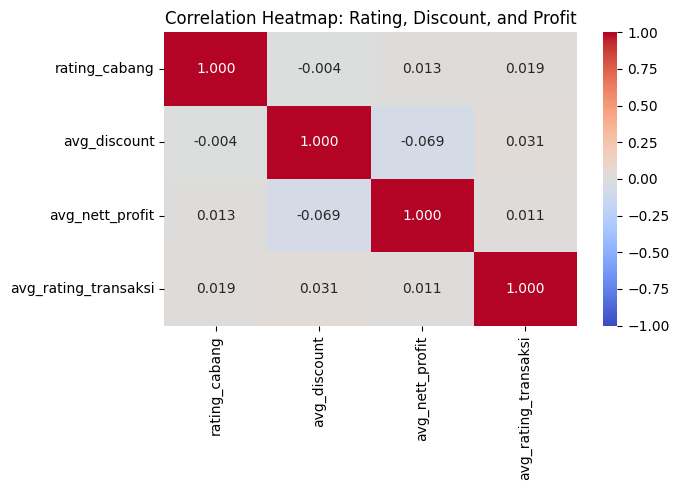

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns relevant to our hypothesis
corr_columns = ['rating_cabang', 'avg_discount', 'avg_nett_profit', 'avg_rating_transaksi']
corr_matrix = branch_metrics[corr_columns].corr()

# Plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Rating, Discount, and Profit')
plt.tight_layout()
plt.show()

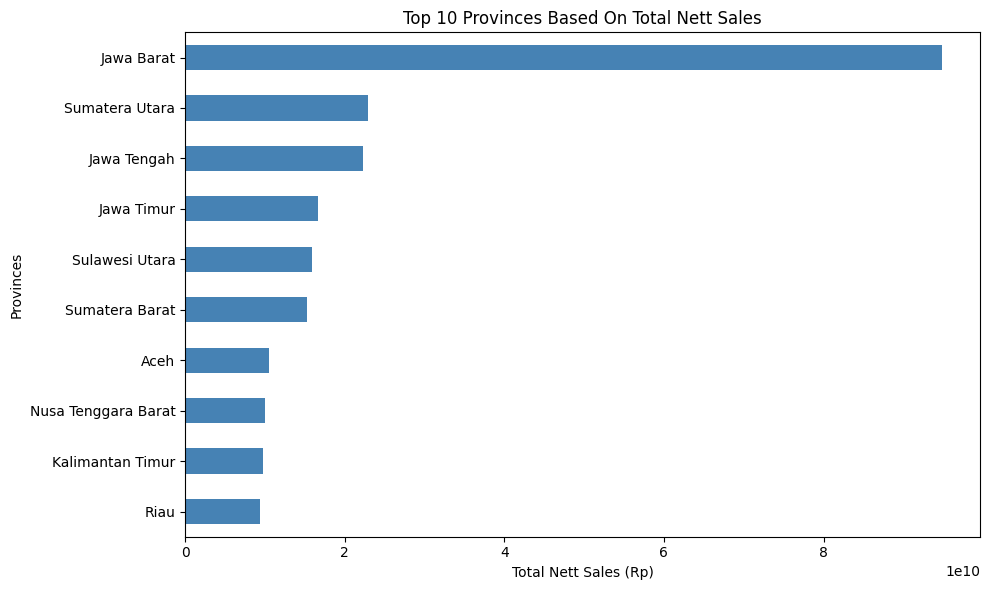

In [ ]:
# Get top 10 provinces by nett sales
top_sales_provinsi = df.groupby('provinsi')['nett_sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_sales_provinsi.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Total Nett Sales (Rp)')
plt.ylabel('Provinces')
plt.title('Top 10 Provinces Based On Total Nett Sales')
plt.tight_layout()
plt.show()

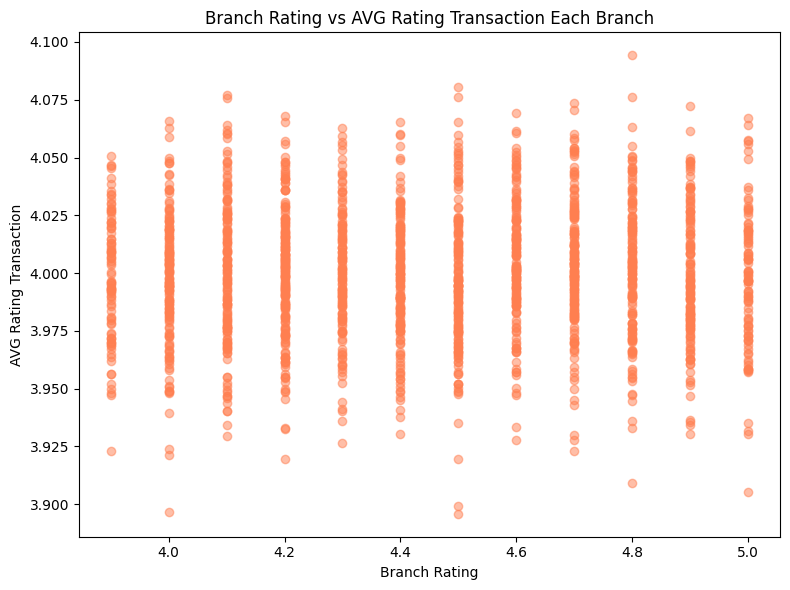

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(branch_metrics['rating_cabang'], branch_metrics['avg_rating_transaksi'], alpha=0.5, color='coral')
plt.xlabel('Branch Rating')
plt.ylabel('AVG Rating Transaction')
plt.title('Branch Rating vs AVG Rating Transaction Each Branch')
plt.tight_layout()
plt.show()

In [ ]:
# Total nett profit per province (data source for the geo map in Looker Studio)
profit_per_province = df.groupby('provinsi')['nett_profit'].sum().sort_values(ascending=False)
print("=== TOTAL NETT PROFIT PER PROVINCE ===")
print(profit_per_province)

print()

# Distribution of transactions across price tiers (persentase_gross_laba)
tier_distribution = df['persentase_gross_laba'].value_counts().sort_index()
tier_pct = (tier_distribution / tier_distribution.sum() * 100).round(1)
print("=== TRANSACTION DISTRIBUTION PER PROFIT TIER ===")
for tier, count in tier_distribution.items():
    print(f"Tier {tier:.0%}: {count:,} transactions ({tier_pct[tier]}%)")

=== TOTAL NETT PROFIT PER PROVINCE ===
provinsi
Jawa Barat             2.694070e+10
Sumatera Utara         6.517187e+09
Jawa Tengah            6.318005e+09
Jawa Timur             4.722765e+09
Sulawesi Utara         4.516325e+09
Sumatera Barat         4.349184e+09
Aceh                   2.973595e+09
Nusa Tenggara Barat    2.848909e+09
Kalimantan Timur       2.761089e+09
Riau                   2.656282e+09
Kepulauan Riau         2.161206e+09
Sumatera Selatan       1.972618e+09
Bali                   1.818322e+09
Gorontalo              1.659405e+09
Kalimantan Selatan     1.403598e+09
Kalimantan Utara       1.361478e+09
Bangka Belitung        1.331168e+09
Kalimantan Barat       1.324852e+09
Sulawesi Tenggara      1.313501e+09
Maluku Utara           1.272887e+09
Maluku                 1.267523e+09
DI Yogyakarta          1.155417e+09
DKI Jakarta            1.101398e+09
Sulawesi Selatan       1.089277e+09
Kalimantan Tengah      1.054204e+09
Banten                 1.047882e+09
Jambi           

# **Additional Analyst - product_category & product_category**

In [ ]:
# Query branch_category from kf_kantor_cabang
query_branch_cat = """
SELECT branch_id, branch_category
FROM `kimia_farma.kf_kantor_cabang`
"""
branch_cat = pandas_gbq.read_gbq(query_branch_cat, project_id=PROJECT_ID)

# Query product_category from kf_product
query_product_cat = """
SELECT product_id, product_category
FROM `kimia_farma.kf_product`
"""
product_cat = pandas_gbq.read_gbq(query_product_cat, project_id=PROJECT_ID)

# Merge both category columns into the main df
df = df.merge(branch_cat, on='branch_id', how='left')
df = df.merge(product_cat, on='product_id', how='left')

print("New columns added:", df.shape[1])
print(df[['branch_category', 'product_category']].head())

Downloading: 100%|██████████|
Downloading: 100%|██████████|
New columns added: 19
  branch_category product_category
0          Apotek              R06
1          Apotek              R06
2          Apotek              R06
3          Apotek              R06
4          Apotek              R06


In [ ]:
# Filter only transactions in the highest profit tier (30%)
tier_30 = df[df['persentase_gross_laba'] == 0.30]

# Count transactions per product category within this tier
category_dist = tier_30['product_category'].value_counts().head(10)
category_pct = (category_dist / len(tier_30) * 100).round(1)

print("=== TOP 10 PRODUCT CATEGORIES IN THE 30% PROFIT TIER ===")
for cat, count in category_dist.items():
    print(f"{cat}: {count:,} transactions ({category_pct[cat]}%)")

=== TOP 10 PRODUCT CATEGORIES IN THE 30% PROFIT TIER ===
R06: 71,801 transactions (20.6%)
M01AE: 58,313 transactions (16.7%)
N02BE/B: 49,202 transactions (14.1%)
N05C: 44,534 transactions (12.8%)
M01AB: 40,343 transactions (11.6%)
N02BA: 31,153 transactions (8.9%)
R03: 26,880 transactions (7.7%)
N05B: 26,689 transactions (7.6%)


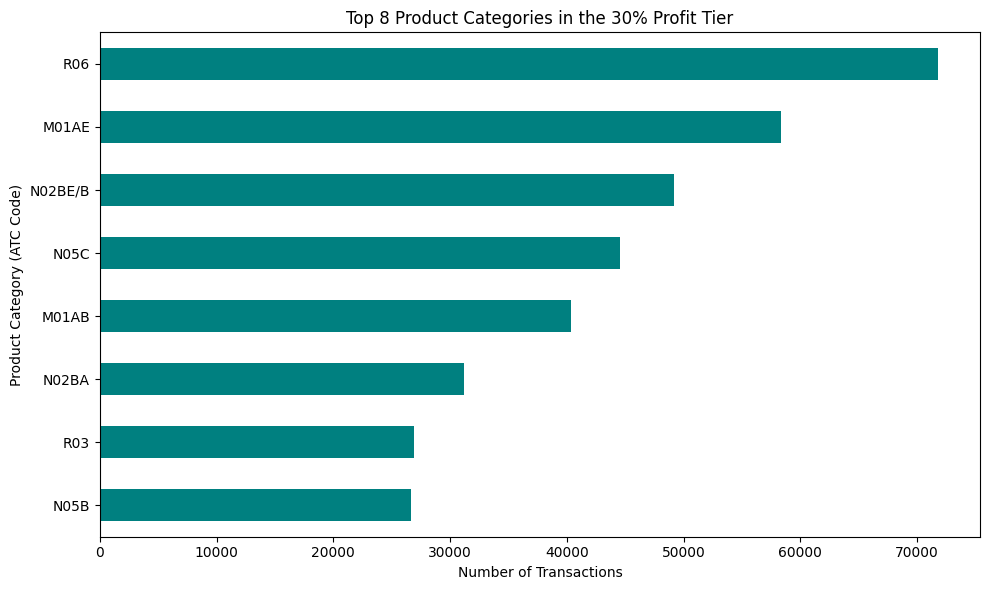

In [ ]:
# Filter only transactions in the highest profit tier (30%)
tier_30 = df[df['persentase_gross_laba'] == 0.30]

# Get top 8 product categories in this tier
category_dist = tier_30['product_category'].value_counts().head(8)

plt.figure(figsize=(10, 6))
category_dist.sort_values().plot(kind='barh', color='teal')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Category (ATC Code)')
plt.title('Top 8 Product Categories in the 30% Profit Tier')
plt.tight_layout()
plt.show()

In [ ]:
# Compare performance metrics across branch categories
branch_cat_summary = df.groupby('branch_category').agg(
    total_transactions=('transaction_id', 'count'),
    total_nett_sales=('nett_sales', 'sum'),
    total_nett_profit=('nett_profit', 'sum'),
    avg_rating_cabang=('rating_cabang', 'mean'),
    avg_rating_transaksi=('rating_transaksi', 'mean')
).reset_index()

print(branch_cat_summary)

              branch_category  total_transactions  total_nett_sales  \
0                      Apotek              227677      1.088892e+11   
1             Klinik & Apotek              222718      1.063201e+11   
2  Klinik-Apotek-Laboratorium              222063      1.059619e+11   

   total_nett_profit  avg_rating_cabang  avg_rating_transaksi  
0       3.093646e+10           4.428663              4.000247  
1       3.018968e+10           4.465328              3.999296  
2       3.008885e+10           4.450397              4.000552  


# **Additional Analyst - Normalize by branch count**

In [ ]:
# Count number of unique branches per province
branches_per_province = df.groupby('provinsi')['branch_id'].nunique()

# Total nett sales per province
sales_per_province = df.groupby('provinsi')['nett_sales'].sum()

# Combine and calculate average sales per branch
province_comparison = pd.DataFrame({
    'num_branches': branches_per_province,
    'total_nett_sales': sales_per_province
})
province_comparison['avg_sales_per_branch'] = province_comparison['total_nett_sales'] / province_comparison['num_branches']
province_comparison = province_comparison.sort_values('avg_sales_per_branch', ascending=False)

print(province_comparison.head(10))

                    num_branches  total_nett_sales  avg_sales_per_branch
provinsi                                                                
Kalimantan Selatan            26      4.930165e+09          1.896217e+08
Jambi                         19      3.601798e+09          1.895683e+08
Gorontalo                     31      5.839731e+09          1.883784e+08
Sumatera Selatan              37      6.939913e+09          1.875652e+08
Bangka Belitung               25      4.685441e+09          1.874176e+08
Riau                          50      9.354616e+09          1.870923e+08
Sulawesi Utara                85      1.590276e+10          1.870913e+08
Jawa Tengah                  119      2.224810e+10          1.869588e+08
Aceh                          56      1.046797e+10          1.869281e+08
Jawa Timur                    89      1.662708e+10          1.868211e+08


In [ ]:
# Check Jawa Barat's rank in the normalized comparison
print(province_comparison.loc['Jawa Barat'])
print()
print("Jawa Barat's rank by avg_sales_per_branch:",
      province_comparison.reset_index().sort_values('avg_sales_per_branch', ascending=False).reset_index(drop=True).query("provinsi == 'Jawa Barat'").index[0] + 1,
      "out of", len(province_comparison))

num_branches            5.100000e+02
total_nett_sales        9.486959e+10
avg_sales_per_branch    1.860188e+08
Name: Jawa Barat, dtype: float64

Jawa Barat's rank by avg_sales_per_branch: 17 out of 31
